<a href="https://colab.research.google.com/github/VainaviS/EndoNet/blob/main/notebooks/Image_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install np_utils
!pip install keras

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for np_utils: filename=np_utils-0.6.0-py3-none-any.whl size=56439 sha256=d84d482104da49fe56f87bc1d36ec9b2cc9b24e69ad06a695cf8422410466596
  Stored in directory: /root/.cache/pip/wheels/b6/c7/50/2307607f44366dd021209f660045f8d51cb976514d30be7cc7
Successfully built np_utils


In [ ]:
import os
os.environ['KERAS_BACKEND']='tensorflow'

In [ ]:
import datetime as dt
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('fivethirtyeight')
sns.set_style('whitegrid')


import os
from keras.applications import xception
from keras.preprocessing import image
from mpl_toolkits.axes_grid1 import ImageGrid
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import cv2
from scipy.stats import uniform

from tqdm import tqdm
from glob import glob


from keras.models import Model, Sequential
from keras.layers import LSTM, Activation, Dense, Dropout, Input, Embedding, Masking
from keras.utils import to_categorical


from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

Mounted at /content/gdrive


In [ ]:
data ='../content/gdrive/MyDrive/EndoObjDetect-main/EndoObjDetect-main/Endo Dataset/Endo'
Test ='../content/gdrive/MyDrive/EndoObjDetect-main/EndoObjDetect-main/Endo Dataset/Endo/Test'
Train='../content/gdrive/MyDrive/EndoObjDetect-main/EndoObjDetect-main/Endo Dataset/Endo/Train'


class_data= ['Test','Train']
len_class_data = len(class_data)

In [ ]:
image_count = {}
train_data = []

for i , class_data in tqdm(enumerate(class_data)):
    class_folder = os.path.join(data,class_data)
    label = class_data
    image_count[class_data] = []

    for path in os.listdir(os.path.join(class_folder)):
        image_count[class_data].append(class_data)
        train_data.append(['{}/{}'.format(class_data, path), i, class_data])

2it [00:00, 233.77it/s]


In [ ]:
#show image count
for key, value in image_count.items():
    print('{0} -> {1}'.format(key, len(value)))

Test -> 94
Train -> 203


In [ ]:
#create a dataframe
df = pd.DataFrame(train_data, columns=['file', 'id', 'label'])
df.shape
df.head()

(297, 3)

,file,id,label
0,Test/55.png,0,Test
1,Test/16.png,0,Test
2,Test/10.png,0,Test
3,Test/32.png,0,Test
4,Test/93.png,0,Test


In [ ]:
#image  deskew function
def  deskew_image(image):
    mask = create_mask_for_image(image)
    output = cv2.bitwise_and(image, image, mask = mask)
    return output/255

In [ ]:
#image  gray  function
def  gray_image(image):
    mask = create_mask_for_image(image)
    output = cv2.cvtColor(image,  cv2.COLOR_BGR2GRAY)
    return output/255

In [ ]:
#image  thresh  function
def  thresh_image(image):
    img = read_img(df['file'][250],(255,255))
    gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    output = cv2.threshold(gray,0,255,cv2.THRESH_BINARY_INV) #+cv.THRESH_OTSU)
    return output

In [ ]:
#image  rnoise  function
def  rnoise_image(image):
    mask = create_mask_for_image(image)
    output = cv2.bitwise_and(image, image, mask = mask)
    return output/255

In [ ]:
#image  dilate  function
def  dilate_image(image):
    mask = create_mask_for_image(image)
    output = cv2.bitwise_and(image, image, mask = mask)
    return output/255


#image  erode  function
def  erode_image(image):
    mask = create_mask_for_image(image)
    output = cv2.bitwise_and(image, image, mask = mask)
    return output/255


#image  opening  function
def  opening_image(image):
    mask = create_mask_for_image(image)
    output = cv2.bitwise_and(image, image, mask = mask)
    return output/255


In [ ]:
#image canny function
def  canny_image(image):
    mask = create_mask_for_image(image)
    output = cv2.bitwise_and(image, image, mask = mask)
    return output/255

In [ ]:
#image segmentation function
def segment_image(image):
    mask = create_mask_for_image(image)
    output = cv2.bitwise_and(image, image, mask = mask)
    return output/255


In [ ]:
#sharpen the image
def sharpen_image(image):
    image_blurred = cv2.GaussianBlur(image, (0, 0), 3)
    image_sharp = cv2.addWeighted(image, 1.5, image_blurred, -0.5, 0)
    return image_sharp


Text(0.5, 0.98, 'IMAGE PREPROCESSING')

[Text(0.0, 0, ''), Text(0.5, 0, ''), Text(1.0, 0, '')]

[Text(0, 0.0, ''), Text(0, 0.5, ''), Text(0, 1.0, '')]

[Text(0.0, 0, ''), Text(0.5, 0, ''), Text(1.0, 0, '')]

[Text(0, 0.0, ''), Text(0, 0.5, ''), Text(0, 1.0, '')]

...

[Text(0, 0.0, ''), Text(0, 0.5, ''), Text(0, 1.0, '')]

[Text(0.0, 0, ''), Text(0.5, 0, ''), Text(1.0, 0, '')]

[Text(0, 0.0, ''), Text(0, 0.5, ''), Text(0, 1.0, '')]

[Text(0.0, 0, ''), Text(0.5, 0, ''), Text(1.0, 0, '')]

[Text(0, 0.0, ''), Text(0, 0.5, ''), Text(0, 1.0, '')]

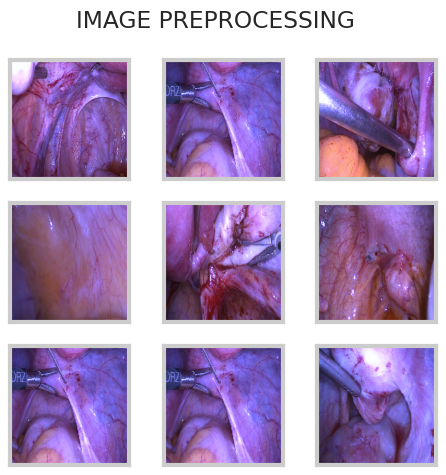

In [ ]:
import os
import numpy as np
from keras.preprocessing import image
import matplotlib.pyplot as plt

def read_img(filepath, size):
    img = image.load_img(os.path.join(data, filepath), target_size=size)
    # convert image to array
    img = image.img_to_array(img)
    return img

nb_rows = 3
nb_cols = 3
fig, axs = plt.subplots(nb_rows, nb_cols, figsize=(5, 5))
plt.suptitle('IMAGE PREPROCESSING')

for i in range(0, nb_rows):
    for j in range(0, nb_cols):
        axs[i, j].xaxis.set_ticklabels([])
        axs[i, j].yaxis.set_ticklabels([])
        img = read_img(df['file'][np.random.randint(70)], (255, 255))
        # Increase blue channel intensity
        img[:, :, 2] *= 2  # Adjust the multiplication factor as needed
        # Clip values to ensure they remain in valid range [0, 255]
        img = np.clip(img, 0, 255)
        axs[i, j].imshow(img.astype(np.uint8))  # Convert back to uint8
for ax in axs.flatten():
    ax.grid(False)

plt.show()
